In [14]:
import numpy as np
import pickle, gzip
from plotting import plot_custom_corner, display_latex_constraints_table
from astropy.cosmology import Flatw0waCDM
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Free $\sigma_{\beta_{\rm E}}$ Forecast

In [15]:
# --- 1. SHARED CONFIGURATION & COSMOLOGY ---
# We define the true underlying universe that all mocks will be generated from.
cosmo_true = Flatw0waCDM(H0=70.0, Om0=0.3, w0=-1.0, wa=0.0)

# True population parameters for the Mass Sheet Transform (MST) and power-law slope
shared_truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.078, 'gamma_sigma': 0.16
}

# Constant observational errors: measurement error + line-of-sight variance
sig_meas, sig_los = 0.01, 0.01
sig_meas_rel = np.sqrt(sig_meas**2 + sig_los**2)

# Global fixed parameters (Gamma and its scatter are fixed for all runs)
global_fixed_params = {
    'h0': 70.0, 
    'gamma_pl': shared_truth['gamma_pl'], 
    'gamma_sigma': shared_truth['gamma_sigma'],
    'beta_c2': 0.0 # Keep quadratic scatter off for all runs to avoid overfitting
}

# --- 2. GENERATE THE DATASETS ---
print("Generating Mock Catalogs...")
np.random.seed(42) # so we evaluate identical datasets across scripts.

def generate_catalog(num_lenses, down_sampling, true_scatter, redshift_error, dissimilarity):
    """Generates a list of mock lens dictionaries ready for the likelihood function."""
    catalog = []
    for _ in range(num_lenses):
        # Draw realistic redshift distributions (Lens at ~0.5, sources stretching behind it)
        z_lens = np.random.normal(loc=0.5, scale=0.1)
        z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
        z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
        
        catalog.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=shared_truth['lambda_int'], lambda_mst_sigma=shared_truth['lambda_sigma'],
            gamma_pl_mean=shared_truth['gamma_pl'], gamma_pl_sigma=shared_truth['gamma_sigma'],
            sigma_beta_intrinsic=true_scatter, sigma_meas_rel=sig_meas_rel,
            dissimilarity=dissimilarity, down_sampling=down_sampling, 
            with_noise=False, cosmo=cosmo_true, redshift_error_rel=redshift_error
        ))
    return catalog

# ================= FULL MISSION CATALOGS (2415 deg²) =================
# 1. Roman DSPL (Expected ~500 total). Spec-z precision, 0% intrinsic scatter.
dspl_catalog = generate_catalog(num_lenses=500, down_sampling=1, true_scatter=0.0, redshift_error=0.001, dissimilarity=0.0)

# 2. Roman PDSPL (Expected ~70,000 total). Photo-z errors, 10% beta_E scatter.
# We simulate 700 lenses but apply a down_sampling weight of 100 (700 * 100 = 70,000 effective lenses).
pdspl_catalog = generate_catalog(num_lenses=700, down_sampling=100, true_scatter=0.10, redshift_error=0.01, dissimilarity=0.0)

# 3. Full Mission Joint Component 
# We generate the PDSPLs again, but this time set dissimilarity=1.0 so the MCMC can mathematically isolate their scatter from the DSPLs.
pdspl_joint_catalog = generate_catalog(num_lenses=700, down_sampling=100, true_scatter=0.10, redshift_error=0.01, dissimilarity=1.0)
joint_catalog_full = dspl_catalog + pdspl_joint_catalog

# ================= EARLY SCIENCE CATALOGS (Roman Medium 450 deg²) =================
# 4. Early Science DSPLs: Scale 500 total lenses by (450/2415) = ~93 lenses. Simulate all 93 directly.
dspl_450_catalog = generate_catalog(num_lenses=93, down_sampling=1, true_scatter=0.0, redshift_error=0.001, dissimilarity=0.0)

# 5. Early Science PDSPLs: Scale 70,000 total lenses by (450/2415) = ~13,000 lenses. 
# We simulate 500 lenses with a down_sampling weight of 26 (500 * 26 = 13,000 effective lenses).
pdspl_450_joint_catalog = generate_catalog(num_lenses=500, down_sampling=26, true_scatter=0.10, redshift_error=0.01, dissimilarity=1.0)
joint_catalog_450 = dspl_450_catalog + pdspl_450_joint_catalog


# --- 3. PRIORS ---
# Baseline Priors (Uniform across physical bounds)
my_priors_base = {
    'om': ('uniform', 0.0, 1.0), 'w0': ('uniform', -3.0, 0.0), 'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2), 'lambda_sigma': ('uniform', 0.0, 0.2),
    'beta_c0': ('uniform', -0.5, 0.5), 'beta_c1': ('uniform', -0.5, 0.5)
}

# Pantheon+ Prior (Centered on true Om=0.3 to prevent biasing the mock, with ~0.018 standard deviation)
my_priors_pantheon = my_priors_base.copy()
my_priors_pantheon['om'] = ('gaussian', 0.3, 0.018)


# --- 4. SCENARIOS (FREE SCATTER ONLY) ---
scenarios = {
    # ================= NO EXTERNAL PRIOR =================
    # For isolated populations, we just sample beta_c0 as the global scatter term.
    # 'Roman DSPL (Free)': {
    #     'data': dspl_catalog, 'color': '#ff7f0e',
    #     'fixed_params': {**global_fixed_params, 'beta_c1': 0.0},
    #     'priors': my_priors_base, 'label': 'Roman DSPL Only\nN=500 (Spec-z)', 'true_scatter': 0.0
    # },
    # 'Roman PDSPL (Free)': {
    #     'data': pdspl_catalog, 'color': '#1f77b4',
    #     'fixed_params': {**global_fixed_params, 'beta_c1': 0.0}, 
    #     'priors': my_priors_base, 'label': 'Roman PDSPL Only\nN=70k (Photo-z)', 'true_scatter': 0.10
    # },
    
    # # For joint populations, we use the dissimilarity trick.
    # # We LOCK beta_c0 = 0.0. Since DSPLs have dissimilarity=0, their scatter is locked to 0.0.
    # # We SAMPLE beta_c1. Since PDSPLs have dissimilarity=1.0, their scatter becomes strictly beta_c1.
    # 'Roman Medium 450 deg2 (Free)': {
    #     'data': joint_catalog_450, 'color': '#2ca02c',
    #     'fixed_params': {**global_fixed_params, 'beta_c0': 0.0},
    #     'priors': my_priors_base, 'label': 'Roman Early Science (450 deg²)\n93 DSPLs + 13k PDSPLs', 'true_scatter': 0.10
    # },
    # 'Joint DSPL + PDSPL (Free)': {
    #     'data': joint_catalog_full, 'color': '#d62728',
    #     'fixed_params': {**global_fixed_params, 'beta_c0': 0.0}, 
    #     'priors': my_priors_base, 'label': 'Roman Full Mission (2415 deg²)\n500 DSPLs + 70k PDSPLs', 'true_scatter': 0.10 
    # },

    # ================= PANTHEON+ PRIOR =================
    # Exact same likelihood structure, but feeding in the external Pantheon+ Omega_m constraint.
    # 'Roman DSPL (Free + Pan+)': {
    #     'data': dspl_catalog, 'color': '#9467bd',
    #     'fixed_params': {**global_fixed_params, 'beta_c1': 0.0},
    #     'priors': my_priors_pantheon, 'label': 'Roman DSPL Only\nN=500 (Pan+ Prior)', 'true_scatter': 0.0
    # },
    # 'Roman PDSPL (Free + Pan+)': {
    #     'data': pdspl_catalog, 'color': '#8c564b',
    #     'fixed_params': {**global_fixed_params, 'beta_c1': 0.0}, 
    #     'priors': my_priors_pantheon, 'label': 'Roman PDSPL Only\nN=70k (Pan+ Prior)', 'true_scatter': 0.10
    # },
    'Roman Medium 450 deg2 (Free + Pan+)': {
        'data': joint_catalog_450, 'color': '#c5b0d5',
        'fixed_params': {**global_fixed_params, 'beta_c0': 0.0},
        'priors': my_priors_pantheon, 'label': 'Roman Early Science (450 deg²)\nJoint Forecast (Pan+ Prior)', 'true_scatter': 0.10
    },
    'Joint DSPL + PDSPL (Free + Pan+)': {
        'data': joint_catalog_full, 'color': '#c49c94',
        'fixed_params': {**global_fixed_params, 'beta_c0': 0.0}, 
        'priors': my_priors_pantheon, 'label': 'Roman Full Mission (2415 deg²)\nJoint Forecast (Pan+ Prior)', 'true_scatter': 0.10 
    }
}

# Initial guesses and tightly packed starting spreads for the MCMC walkers
my_guess = {'om': 0.3, 'w0': -1.0, 'wa': 0.0, 'lambda_int': 1.0, 'lambda_sigma': 0.05, 'beta_c0': 0.10, 'beta_c1': 0.10}
my_spreads = {'om': 0.05, 'w0': 0.05, 'wa': 0.05, 'lambda_int': 0.05, 'lambda_sigma': 0.02, 'beta_c0': 0.02, 'beta_c1': 0.02}

# --- 5. RUN INFERENCE ---
results_free = {}
for key, sc in scenarios.items():
    print(f"\n{'='*60}\nRunning Inference: {key}\n{'='*60}")
    
    # The likelihood function inside run_dspl_inference will automatically detect 
    # which parameters are missing from 'fixed_params' and sample them.
    samples, labels = run_dspl_inference(
        sc['data'], n_walkers=64, n_steps=1000, n_burn=200,
        initial_guess=my_guess, initial_scatter=my_spreads, 
        fixed_params=sc['fixed_params'], priors=sc['priors']
    )
    results_free[key] = {'samples': samples, 'labels': labels, 'color': sc['color'], 'label': sc['label'], 'true_scatter': sc['true_scatter']}

# save everything to pickle
# with gzip.open("data/roman_pdspl_forecast_results_free_v2.pkl.gz", "wb") as f:
#     pickle.dump(results_free, f)

Generating Mock Catalogs...

Running Inference: Roman Medium 450 deg2 (Free + Pan+)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'gamma_pl', 'gamma_sigma', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'beta_c1']


100%|██████████| 1000/1000 [05:44<00:00,  2.91it/s]



Running Inference: Joint DSPL + PDSPL (Free + Pan+)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'gamma_pl', 'gamma_sigma', 'beta_c2', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'beta_c1']


100%|██████████| 1000/1000 [08:14<00:00,  2.02it/s]


In [ ]:
# load from pickle (for plotting only)
# with gzip.open("data/roman_pdspl_forecast_results_free_v2.pkl.gz", "rb") as f:
#     results_free = pickle.load(f)

### Forecast Figures (Free Scatter)


Generating plot for: Roman Medium 450 deg2 (Free + Pan+) vs Joint DSPL + PDSPL (Free + Pan+)


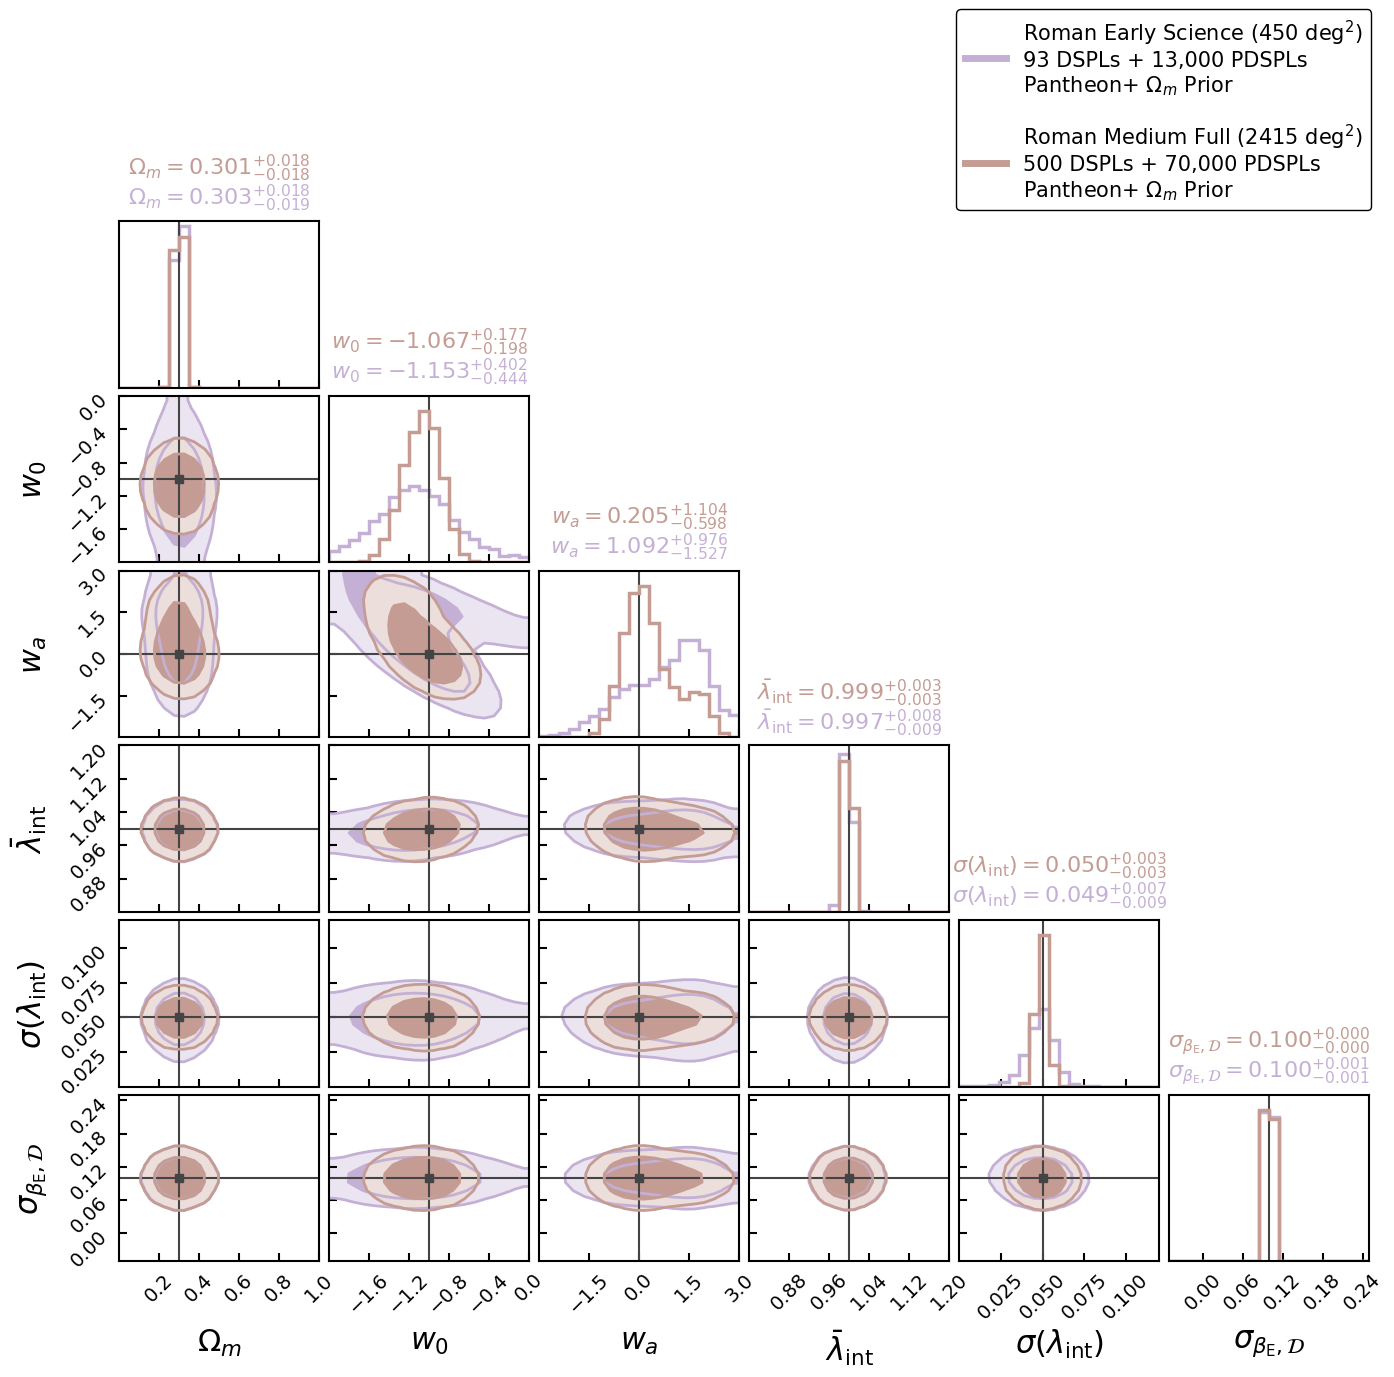

In [20]:
FIGURES_DIR = "proposal_figures_v2/"

# =====================================================================
# --- PLOTTING DEFINITIONS ---
# =====================================================================

# Parameter list for Free Scatter (includes the inferred effective scatter)
params_all_free = [r"$\Omega_m$", r"$w_0$", r"$w_a$", r"$\bar{\lambda}_{\rm int}$", r"$\sigma({\lambda}_{\rm int})$", r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}$"]

# Subset list for the specific tight-constraint plots
params_subset = [r"$w_0$", r"$w_a$", r"$\bar{\lambda}_{\rm int}$", r"$\sigma({\lambda}_{\rm int})$"]

# Custom bounds to zoom in on the tight w0/wa contours for the subset plots
zoomed_ranges = {
    # r"$w_0$": (-1.3, -0.7),
    # r"$w_a$": (-1.5, 1.5)
}

# =====================================================================
# --- PART 1: FREE SCATTER PLOTS ---
# =====================================================================
# print("\nGenerating Free Scatter Plots...")

# # 1. Base Populations (No Priors, All Parameters)
# custom_legend_free_no_prior = {
#     'Roman DSPL (Free)': 'Roman DSPL Only (2415 deg$^2$)\n500 Lenses (Spec-z)\nNo External Prior',
#     'Roman PDSPL (Free)': 'Roman PDSPL Only (2415 deg$^2$)\n700,000 Lenses (Photo-z)\nNo External Prior',
#     'Joint DSPL + PDSPL (Free)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 700,000 PDSPLs\nNo External Prior'
# }

# plot_custom_corner(
#     results=results_free,
#     scenario_keys=['Roman DSPL (Free)', 'Roman PDSPL (Free)', 'Joint DSPL + PDSPL (Free)'],
#     params_to_plot=params_all_free,
#     custom_legend_labels=custom_legend_free_no_prior, 
#     filename=f"{FIGURES_DIR}Free_1_Base_Populations.png"
# )

# # 2. Base Populations WITH Pantheon+ Prior (Subset Parameters)
# custom_legend_free_with_prior = {
#     'Roman DSPL (Free + Pan+)': 'Roman DSPL Only (2415 deg$^2$)\n500 Lenses (Spec-z)\nPantheon+ $\\Omega_m$ Prior',
#     'Roman PDSPL (Free + Pan+)': 'Roman PDSPL Only (2415 deg$^2$)\n700,000 Lenses (Photo-z)\nPantheon+ $\\Omega_m$ Prior',
#     'Joint DSPL + PDSPL (Free + Pan+)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 700,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior'
# }

# plot_custom_corner(
#     results=results_free,
#     scenario_keys=['Roman DSPL (Free + Pan+)', 'Roman PDSPL (Free + Pan+)', 'Joint DSPL + PDSPL (Free + Pan+)'],
#     params_to_plot=params_subset, 
#     custom_legend_labels=custom_legend_free_with_prior,
#     param_ranges=zoomed_ranges,
#     filename=f"{FIGURES_DIR}Free_2_Base_Populations_With_Prior.png"
# )

# # 3. Impact of Pantheon+ Prior on the Joint Run (Subset Parameters)
# custom_legend_free_prior_impact = {
#     'Joint DSPL + PDSPL (Free)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 700,000 PDSPLs\nNo External Prior',
#     'Joint DSPL + PDSPL (Free + Pan+)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 700,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior'
# }

# plot_custom_corner(
#     results=results_free,
#     scenario_keys=['Joint DSPL + PDSPL (Free)', 'Joint DSPL + PDSPL (Free + Pan+)'],
#     params_to_plot=params_subset,
#     custom_legend_labels=custom_legend_free_prior_impact,
#     param_ranges=zoomed_ranges,
#     filename=f"{FIGURES_DIR}Free_3_Prior_Impact_on_Joint.png"
# )

# # 4. Early Science (450 sq. deg) vs Full Mission (Subset Parameters)
# custom_legend_free_timeline = {
#     'Roman Medium 450 deg2 (Free)': 'Roman Early Science (450 deg$^2$)\n93 DSPLs + 130,000 PDSPLs\nNo External Prior',
#     'Joint DSPL + PDSPL (Free)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 700,000 PDSPLs\nNo External Prior'
# }

# plot_custom_corner(
#     results=results_free,
#     scenario_keys=['Roman Medium 450 deg2 (Free)', 'Joint DSPL + PDSPL (Free)'],
#     params_to_plot=params_subset,
#     custom_legend_labels=custom_legend_free_timeline,
#     filename=f"{FIGURES_DIR}Free_4_Early_Science_vs_Full.png"
# )

# 5. Early Science (450 sq. deg) vs Full Mission WITH Pantheon+ Prior (Subset Parameters)
custom_legend_free_timeline_prior = {
    'Roman Medium 450 deg2 (Free + Pan+)': 'Roman Early Science (450 deg$^2$)\n93 DSPLs + 13,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior',
    'Joint DSPL + PDSPL (Free + Pan+)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 70,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior'
}

plot_custom_corner(
    results=results_free,
    scenario_keys=['Roman Medium 450 deg2 (Free + Pan+)', 'Joint DSPL + PDSPL (Free + Pan+)'],
    params_to_plot=params_all_free,
    custom_legend_labels=custom_legend_free_timeline_prior,
    param_ranges=zoomed_ranges,
    filename=f"{FIGURES_DIR}Free_5_Early_Science_vs_Full_With_Prior.png"
)


Generating plot for: Roman Medium 450 deg2 (Free + Pan+) vs Joint DSPL + PDSPL (Free + Pan+)


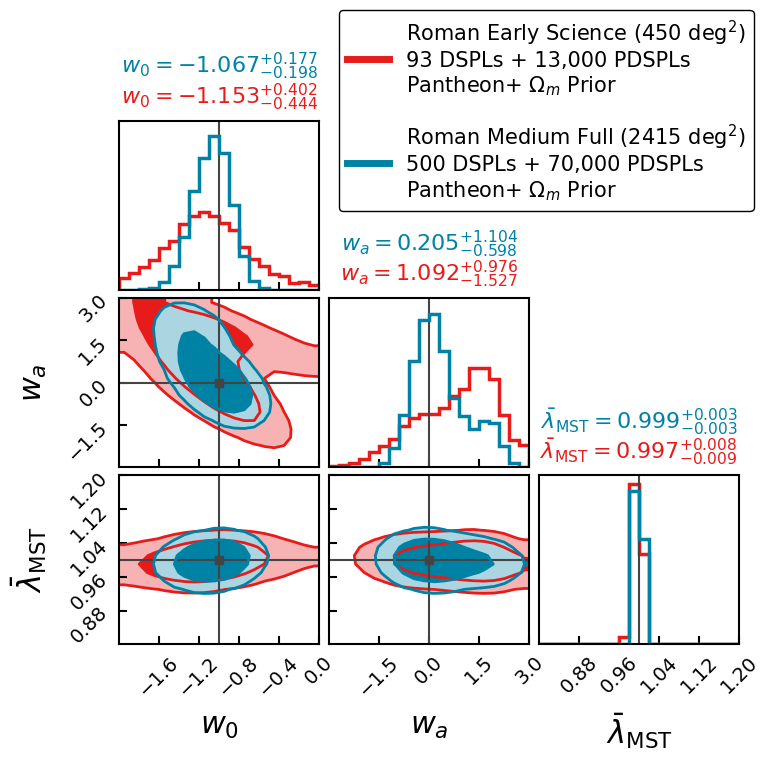

In [21]:
FIGURES_DIR = "proposal_figures_v2/"

# =====================================================================
# --- PLOTTING DEFINITIONS ---
# =====================================================================

# Parameter list for Free Scatter (includes the inferred effective scatter)
params_all_free = [r"$\Omega_m$", r"$w_0$", r"$w_a$", r"$\bar{\lambda}_{\rm int}$", r"$\sigma({\lambda}_{\rm int})$", r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}$"]

# Subset list for the specific tight-constraint plots
params_subset = [r"$w_0$", r"$w_a$", r"$\bar{\lambda}_{\rm int}$"]

# Custom bounds to zoom in on the tight w0/wa contours for the subset plots
zoomed_ranges = {
    # r"$w_0$": (-1.3, -0.7),
    # r"$w_a$": (-1.5, 1.5)
}

# 5. Early Science (450 sq. deg) vs Full Mission WITH Pantheon+ Prior (Subset Parameters)
custom_legend_free_timeline_prior = {
    'Roman Medium 450 deg2 (Free + Pan+)': 'Roman Early Science (450 deg$^2$)\n93 DSPLs + 13,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior',
    'Joint DSPL + PDSPL (Free + Pan+)': 'Roman Medium Full (2415 deg$^2$)\n500 DSPLs + 70,000 PDSPLs\nPantheon+ $\\Omega_m$ Prior'
}

custom_colors = {
    'Roman Medium 450 deg2 (Free + Pan+)': "#e81b1b",
    'Joint DSPL + PDSPL (Free + Pan+)': "#0082a5"
}

custom_param_labels = {
    r"$\Omega_m$": r"$\Omega_m$",
    r"$w_0$": r"$w_0$",
    r"$w_a$": r"$w_a$",
    r"$\bar{\lambda}_{\rm int}$": r"$\bar{\lambda}_{\rm MST}$",
    r"$\sigma({\lambda}_{\rm int})$": r"$\sigma({\lambda}_{\rm MST})$",
    r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}$": r"$\sigma_{\beta_{\rm E}, \mathcal{D}}$"
}

plot_custom_corner(
    results=results_free,
    scenario_keys=['Roman Medium 450 deg2 (Free + Pan+)', 'Joint DSPL + PDSPL (Free + Pan+)'],
    params_to_plot=params_subset,
    custom_legend_labels=custom_legend_free_timeline_prior,
    param_ranges=zoomed_ranges,
    custom_colors=custom_colors,
        custom_param_labels=custom_param_labels,
    filename=f"{FIGURES_DIR}Free_5_Early_Science_vs_Full_With_Prior_small.png"
)